In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 2.2 MB/s eta 0:00:00


In [ ]:
%cd /content/drive/MyDrive/drowisiness_tinyml

/content/drive/MyDrive/drowisiness_tinyml


In [ ]:
!pip install tensorflow_model_optimization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 5.4 MB/s eta 0:00:00


# **KAN_image_size_150_150**

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt
# --- Load and Process New Grayscale Dataset ---
directory = "/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris"
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 150

# Load dataset in grayscale mode
train_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.3, subset='training'
)
test_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.2, subset='validation'
)
valid_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.1, subset='validation'
)

# Convert dataset into NumPy arrays
def dataset_to_numpy(dataset):
    images, labels = [], []
    for batch in dataset:
        batch_images, batch_labels = batch
        images.extend(batch_images.numpy() / 255.0)  # Normalize
        labels.extend(batch_labels.numpy())
    return np.array(images), np.array(labels)

train_images, train_labels = dataset_to_numpy(train_ds)
test_images, test_labels = dataset_to_numpy(test_ds)
valid_images, valid_labels = dataset_to_numpy(valid_ds)

# Flatten images (150x150 → 22500 features)
train_images = train_images.reshape((-1, 150 * 150)).astype('float32')
test_images = test_images.reshape((-1, 150 * 150)).astype('float32')
valid_images = valid_images.reshape((-1, 150 * 150)).astype('float32')

Found 16839 files belonging to 2 classes.
Using 11788 files for training.
Found 16839 files belonging to 2 classes.
Using 3367 files for validation.
Found 16839 files belonging to 2 classes.
Using 1683 files for validation.



🚀 Epoch 1/20
✅ Training Accuracy: 0.5229 | Validation Accuracy: 0.5401 | Training Loss: 0.7638 | Validation Loss: 0.6971

🚀 Epoch 2/20
✅ Training Accuracy: 0.5229 | Validation Accuracy: 0.5401 | Training Loss: 0.6752 | Validation Loss: 0.6222

🚀 Epoch 3/20
✅ Training Accuracy: 0.9214 | Validation Accuracy: 0.9180 | Training Loss: 0.5118 | Validation Loss: 0.4340

🚀 Epoch 4/20
✅ Training Accuracy: 0.9895 | Validation Accuracy: 0.9851 | Training Loss: 0.3192 | Validation Loss: 0.2848

🚀 Epoch 5/20
✅ Training Accuracy: 0.9980 | Validation Accuracy: 0.9976 | Training Loss: 0.2025 | Validation Loss: 0.1632

🚀 Epoch 6/20
✅ Training Accuracy: 0.9986 | Validation Accuracy: 0.9988 | Training Loss: 0.1387 | Validation Loss: 0.1249

🚀 Epoch 7/20
✅ Training Accuracy: 0.9992 | Validation Accuracy: 0.9988 | Training Loss: 0.1067 | Validation Loss: 0.0929

🚀 Epoch 8/20
✅ Training Accuracy: 0.9993 | Validation Accuracy: 0.9994 | Training Loss: 0.0847 | Validation Loss: 0.0755

🚀 Epoch 9/20
✅ Training

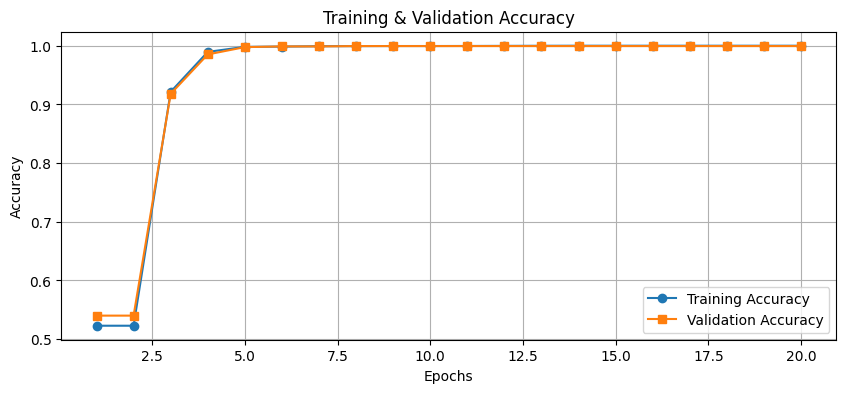

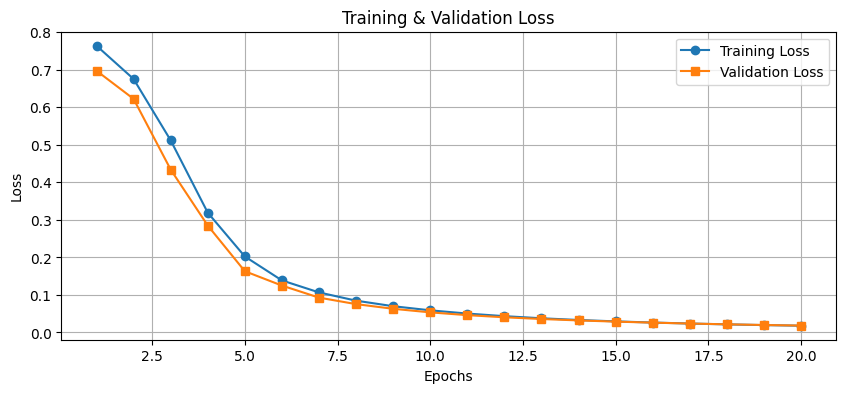

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt

# Define FastKAN model with modified architecture
class RadialBasisFunction(layers.Layer):
    def __init__(self, grid_min, grid_max, num_grids, **kwargs):
        super(RadialBasisFunction, self).__init__(**kwargs)
        self.grid = tf.cast(tf.linspace(grid_min, grid_max, num_grids), dtype=tf.float32)
        self.denominator = tf.cast((grid_max - grid_min) / num_grids, dtype=tf.float32)

    def call(self, x):
        return tf.exp(-((x[..., None] - self.grid) / self.denominator) ** 2)

class FastKANLayer(layers.Layer):
    def __init__(self, input_dim, output_dim, grid_min, grid_max, num_grids, use_base_update, base_activation):
        super(FastKANLayer, self).__init__()
        self.norm = layers.LayerNormalization(axis=-1)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = layers.Dense(output_dim)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = layers.Dense(output_dim)

    def call(self, x):
        x_norm = self.norm(x)
        spline_basis = self.rbf(x_norm)
        spline_basis_flat = tf.reshape(spline_basis, [tf.shape(spline_basis)[0], -1])
        ret = self.spline_linear(spline_basis_flat)
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

class FastKAN(tf.keras.Model):
    def __init__(self, layers_hidden, grid_min=-1, grid_max=1, num_grids=2, use_base_update=False, base_activation=tf.nn.silu):
        super(FastKAN, self).__init__()
        self.layers_list = []
        for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:]):
            self.layers_list.append(FastKANLayer(in_dim, out_dim, grid_min, grid_max, num_grids, use_base_update, base_activation))

    def call(self, inputs):
        x = inputs
        for layer in self.layers_list:
            x = layer(x)
        return x

# Define optimized KAN model
def create_kan():
    return FastKAN([150 * 150, 5, 2], grid_min=-1, grid_max=1, num_grids=2, use_base_update=True, base_activation=tf.nn.silu)

model = create_kan()

# Define optimizer and loss function
optimizer = optimizers.Adam(learning_rate=1e-3)
loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)
accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

# Model Training Parameters
EPOCHS = 20
BATCH_SIZE = 256

# Define function to compute validation loss
def compute_loss(images, labels):
    logits = model(images)
    return loss_fn(labels, logits).numpy()

# Function to compute accuracy
def compute_accuracy(images, labels):
    logits = model(images)
    predictions = tf.argmax(logits, axis=1)
    correct = tf.cast(tf.equal(predictions, labels), dtype=tf.float32)
    return tf.reduce_mean(correct)

# Training Loop
train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], []

for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")

    epoch_train_loss = 0
    num_batches = 0

    # Training loop
    for step in range(0, len(train_images), BATCH_SIZE):
        x_batch_train = train_images[step:step + BATCH_SIZE]
        y_batch_train = train_labels[step:step + BATCH_SIZE]

        with tf.GradientTape() as tape:
            logits = model(x_batch_train)
            loss_value = loss_fn(y_batch_train, logits)

        grads = tape.gradient(loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

        epoch_train_loss += loss_value.numpy()
        num_batches += 1

    # Compute average training loss
    avg_train_loss = epoch_train_loss / num_batches
    train_loss_list.append(avg_train_loss)

    # Compute accuracy
    train_acc = compute_accuracy(train_images, train_labels).numpy()
    val_acc = compute_accuracy(valid_images, valid_labels).numpy()

    # Compute validation loss
    val_loss = compute_loss(valid_images, valid_labels)
    val_loss_list.append(val_loss)

    print(f"✅ Training Accuracy: {train_acc:.4f} | Validation Accuracy: {val_acc:.4f} | Training Loss: {avg_train_loss:.4f} | Validation Loss: {val_loss:.4f}")

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

model.save("kan150_150.keras")

# Plot Accuracy Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_acc_list, label="Training Accuracy", marker='o')
plt.plot(range(1, EPOCHS+1), val_acc_list, label="Validation Accuracy", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.grid()
plt.show()

# Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_loss_list, label="Training Loss", marker='o')
plt.plot(range(1, EPOCHS+1), val_loss_list, label="Validation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.grid()
plt.show()


🚀 Building FastKAN with layers: [22500, 5, 2]
🔹 Initialized Radial Basis Function with 2 grids between [-1, 1]
✅ Initialized FastKANLayer: 22500 → 5 | Base Activation: swish
🔹 Initialized Radial Basis Function with 2 grids between [-1, 1]
✅ Initialized FastKANLayer: 5 → 2 | Base Activation: swish

🚀 Epoch 1/20
✅ Training Accuracy: 0.7380 | Validation Accuracy: 0.7308 | Training Loss: 0.8950 | Validation Loss: 0.5345

🚀 Epoch 2/20
✅ Training Accuracy: 0.8998 | Validation Accuracy: 0.9026 | Training Loss: 0.4981 | Validation Loss: 0.4310

🚀 Epoch 3/20
✅ Training Accuracy: 0.9647 | Validation Accuracy: 0.9596 | Training Loss: 0.3422 | Validation Loss: 0.2664

🚀 Epoch 4/20
✅ Training Accuracy: 0.9711 | Validation Accuracy: 0.9703 | Training Loss: 0.2333 | Validation Loss: 0.2077

🚀 Epoch 5/20
✅ Training Accuracy: 0.9891 | Validation Accuracy: 0.9863 | Training Loss: 0.1796 | Validation Loss: 0.1611

🚀 Epoch 6/20
✅ Training Accuracy: 0.9979 | Validation Accuracy: 0.9976 | Training Loss: 0.

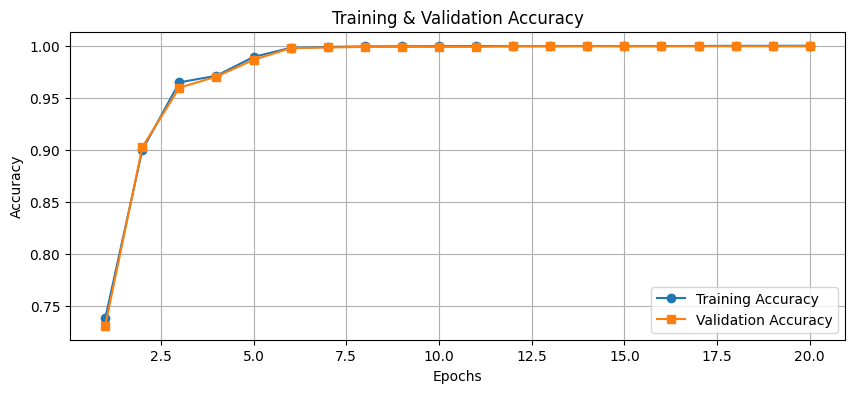

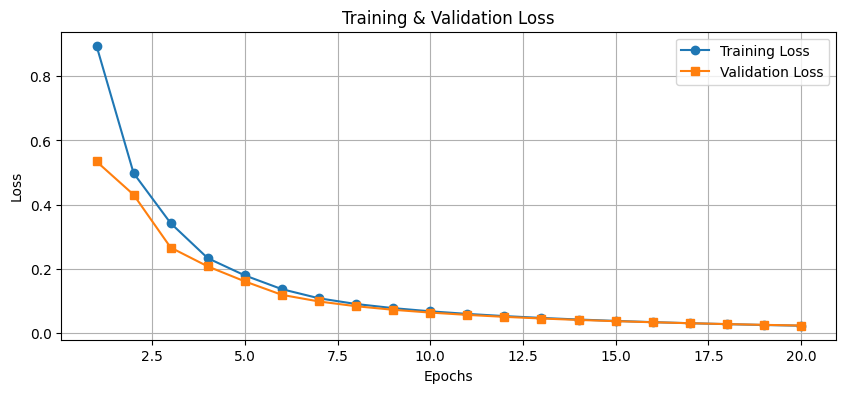

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt

# Define FastKAN model with modified architecture
class RadialBasisFunction(layers.Layer):
    def __init__(self, grid_min, grid_max, num_grids, **kwargs):
        super(RadialBasisFunction, self).__init__(**kwargs)
        self.grid = tf.cast(tf.linspace(grid_min, grid_max, num_grids), dtype=tf.float32)
        self.denominator = tf.cast((grid_max - grid_min) / num_grids, dtype=tf.float32)
        print(f"🔹 Initialized Radial Basis Function with {num_grids} grids between [{grid_min}, {grid_max}]")

    def call(self, x):
        return tf.exp(-((x[..., None] - self.grid) / self.denominator) ** 2)


class FastKANLayer(layers.Layer):
    def __init__(self, input_dim, output_dim, grid_min, grid_max, num_grids, use_base_update, base_activation):
        super(FastKANLayer, self).__init__()
        self.norm = layers.LayerNormalization(axis=-1)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = layers.Dense(output_dim)
        self.use_base_update = use_base_update
        self.base_activation_name = base_activation.__name__ if callable(base_activation) else "None"

        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = layers.Dense(output_dim)

        print(f"✅ Initialized FastKANLayer: {input_dim} → {output_dim} | Base Activation: {self.base_activation_name}")

    def call(self, x):
        x_norm = self.norm(x)
        spline_basis = self.rbf(x_norm)
        spline_basis_flat = tf.reshape(spline_basis, [tf.shape(spline_basis)[0], -1])
        ret = self.spline_linear(spline_basis_flat)

        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base

        return ret


class FastKAN(tf.keras.Model):
    def __init__(self, layers_hidden, grid_min=-1, grid_max=1, num_grids=2, use_base_update=False, base_activation=tf.nn.silu):
        super(FastKAN, self).__init__()
        self.layers_list = []
        print(f"\n🚀 Building FastKAN with layers: {layers_hidden}")
        for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:]):
            self.layers_list.append(FastKANLayer(in_dim, out_dim, grid_min, grid_max, num_grids, use_base_update, base_activation))

    def call(self, inputs):
        x = inputs
        for layer in self.layers_list:
            x = layer(x)
        return x

# Define optimized KAN model
def create_kan():
    return FastKAN([150 * 150, 5, 2], grid_min=-1, grid_max=1, num_grids=2, use_base_update=True, base_activation=tf.nn.silu)

model = create_kan()

# Define optimizer and loss function
optimizer = optimizers.Adam(learning_rate=1e-3)
loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)
accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

# Model Training Parameters
EPOCHS = 20
BATCH_SIZE = 256

# Define function to compute validation loss
def compute_loss(images, labels):
    logits = model(images)
    return loss_fn(labels, logits).numpy()

# Function to compute accuracy
def compute_accuracy(images, labels):
    logits = model(images)
    predictions = tf.argmax(logits, axis=1)
    correct = tf.cast(tf.equal(predictions, labels), dtype=tf.float32)
    return tf.reduce_mean(correct)

# Training Loop
train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], []

for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")

    epoch_train_loss = 0
    num_batches = 0

    # Training loop
    for step in range(0, len(train_images), BATCH_SIZE):
        x_batch_train = train_images[step:step + BATCH_SIZE]
        y_batch_train = train_labels[step:step + BATCH_SIZE]

        with tf.GradientTape() as tape:
            logits = model(x_batch_train)
            loss_value = loss_fn(y_batch_train, logits)

        grads = tape.gradient(loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

        epoch_train_loss += loss_value.numpy()
        num_batches += 1

    # Compute average training loss
    avg_train_loss = epoch_train_loss / num_batches
    train_loss_list.append(avg_train_loss)

    # Compute accuracy
    train_acc = compute_accuracy(train_images, train_labels).numpy()
    val_acc = compute_accuracy(valid_images, valid_labels).numpy()

    # Compute validation loss
    val_loss = compute_loss(valid_images, valid_labels)
    val_loss_list.append(val_loss)

    print(f"✅ Training Accuracy: {train_acc:.4f} | Validation Accuracy: {val_acc:.4f} | Training Loss: {avg_train_loss:.4f} | Validation Loss: {val_loss:.4f}")

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

# Print Activation Function Parameters After Training
print("\n🔍 **Trained Activation Function Parameters:**")
for layer in model.layers_list:
    if isinstance(layer, FastKANLayer) and layer.use_base_update:
        print(f"Layer: {layer.spline_linear.name}")
        print(f"  Activation Function: {layer.base_activation_name}")
        print(f"  Base Linear Weights Shape: {layer.base_linear.weights[0].shape}")
        print(f"  Base Linear Bias Shape: {layer.base_linear.weights[1].shape}\n")

model.save("kan150_150.keras")

# Plot Accuracy Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_acc_list, label="Training Accuracy", marker='o')
plt.plot(range(1, EPOCHS+1), val_acc_list, label="Validation Accuracy", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.grid()
plt.show()

# Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_loss_list, label="Training Loss", marker='o')
plt.plot(range(1, EPOCHS+1), val_loss_list, label="Validation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.grid()
plt.show()


In [ ]:
# Print the number of trainable and non-trainable parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_variables])
non_trainable_params = total_params - trainable_params

print(f"📌 Total Parameters: {total_params}")
print(f"🔧 Trainable Parameters: {trainable_params}")
print(f"🚫 Non-Trainable Parameters: {non_trainable_params}")


📌 Total Parameters: 382554
🔧 Trainable Parameters: 382554
🚫 Non-Trainable Parameters: 0


In [ ]:
# Print train, validation, and test accuracy
train_acc = compute_accuracy(train_images, train_labels).numpy()
val_acc = compute_accuracy(valid_images, valid_labels).numpy()
test_acc = compute_accuracy(test_images, test_labels).numpy()

print(f"✅ Training Accuracy: {train_acc:.4f}")
print(f"✅ Validation Accuracy: {val_acc:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")


✅ Training Accuracy: 0.9999
✅ Validation Accuracy: 0.9994
✅ Test Accuracy: 0.9994


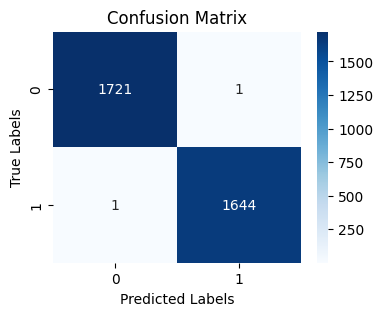

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute predictions
test_predictions = model(test_images)
test_pred_labels = tf.argmax(test_predictions, axis=1).numpy()

# Generate confusion matrix
cm = confusion_matrix(test_labels, test_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt

# Define representative dataset function for integer quantization
def representative_dataset():
    for i in range(100):  # Using a subset of training data
        yield [train_images[i: i + 1]]

# Ensure all variables are frozen before conversion
tf.lite.TFLiteConverter.experimental_new_converter = True

# Export the model to SavedModel format with a signature function
def serving_fn(inputs):
    return {"outputs": model(inputs)}

signature = tf.function(serving_fn).get_concrete_function(
    tf.TensorSpec(shape=[None, 150 * 150], dtype=tf.float32)
)

# Save model in Keras format instead of SavedModel
model.save("kan150_150.keras")

# Convert the model to TFLite format with different quantization methods
# 1. Default Quantization (Dynamic Range)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
dynamic_tflite_model = converter.convert()
with open("kan150_150_dynamic.tflite", "wb") as f:
    f.write(dynamic_tflite_model)
print("✅ Dynamic range quantized model saved as kan150_150_dynamic.tflite")

# 2. Float16 Quantization
converter.target_spec.supported_types = [tf.float16]
float16_tflite_model = converter.convert()
with open("kan150_150_float16.tflite", "wb") as f:
    f.write(float16_tflite_model)
print("✅ Float16 quantized model saved as kan150_150_float16.tflite")

# 3. Full Integer Quantization (with representative dataset)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
integer_tflite_model = converter.convert()
with open("kan150_150_integer.tflite", "wb") as f:
    f.write(integer_tflite_model)
print("✅ Full integer quantized model saved as kan150_150_integer.tflite")

# 4. Weight Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.OPTIMIZE_FOR_SIZE]
weight_tflite_model = converter.convert()
with open("kan150_150_weight.tflite", "wb") as f:
    f.write(weight_tflite_model)
print("✅ Weight quantized model saved as kan150_150_weight.tflite")


Saved artifact at '/tmp/tmp8hcp98uz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 22500), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135830580899536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580896656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580792976: TensorSpec(shape=(2,), dtype=tf.float32, name=None)
  135830580793744: TensorSpec(shape=(), dtype=tf.float32, name=None)
  135830580896848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580898960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580900688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580900496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580901264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580900304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580792016: TensorSpec(sh

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Full integer quantized model saved as kan150_150_integer.tflite
Saved artifact at '/tmp/tmpimicqyi6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 22500), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135830580899536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580896656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580792976: TensorSpec(shape=(2,), dtype=tf.float32, name=None)
  135830580793744: TensorSpec(shape=(), dtype=tf.float32, name=None)
  135830580896848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580898960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580900688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580900496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580901264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135830580900304: TensorSpec(shape=

✅ Weight quantized model saved as kan150_150_weight.tflite


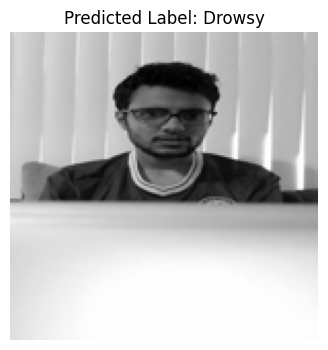

🖼️ Predicted Label: 1 (Drowsy)
⏱️ Inference Time: 1.27 ms


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt
from PIL import Image
import time  # Import time module for inference measurement

# Define representative dataset function for integer quantization
def representative_dataset():
    for i in range(100):  # Using a subset of training data
        yield [train_images[i: i + 1]]

# Ensure all variables are frozen before conversion
tf.lite.TFLiteConverter.experimental_new_converter = True

# Export the model to SavedModel format with a signature function
def serving_fn(inputs):
    return {"outputs": model(inputs)}

signature = tf.function(serving_fn).get_concrete_function(
    tf.TensorSpec(shape=[None, 150 * 150], dtype=tf.float32)
)

# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan150_150_integer.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_13_frame_349.jpg").convert("L")  # Convert to grayscale
image = image.resize((150, 150))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 150 * 150)

# Measure inference time for a single image
start_time = time.time()

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.int8))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

end_time = time.time()
inference_time = (end_time - start_time) * 1000  # Convert to milliseconds

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

# Print results
print(f"🖼️ Predicted Label: {predicted_label} ({predicted_label_name})")
print(f"⏱️ Inference Time: {inference_time:.2f} ms")


In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized dynamic model
interpreter = tf.lite.Interpreter(model_path="kan150_150_integer.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 150 * 150).astype(np.int8)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()
    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 48.86%
⏱️ Total Inference Time for 3367 Images: 3904.43 ms
⏱️ Average Inference Time per Sample: 1.16 ms


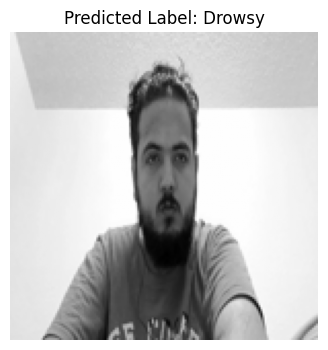

🖼️ Predicted Label: Drowsy


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan150_150_float16.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/drowsy/10_14_frame_15661.jpg").convert("L")  # Convert to grayscale
image = image.resize((150, 150))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 150 * 150)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")

In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized Float16 model
interpreter = tf.lite.Interpreter(model_path="kan150_150_float16.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 150 * 150).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.94%
⏱️ Total Inference Time for 3367 Images: 2937.86 ms
⏱️ Average Inference Time per Sample: 0.87 ms


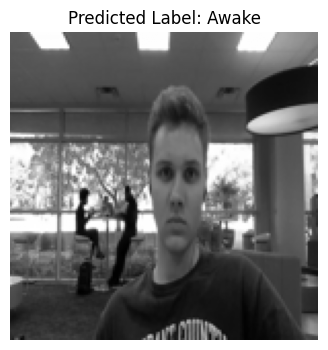

🖼️ Predicted Label: Awake


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan150_150_weight.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_11_frame_10201.jpg").convert("L")  # Convert to grayscale
image = image.resize((150, 150))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 150 * 150)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")


In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized Weight-Only model
interpreter = tf.lite.Interpreter(model_path="kan150_150_weight.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 150 * 150).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.94%
⏱️ Total Inference Time for 3367 Images: 2768.91 ms
⏱️ Average Inference Time per Sample: 0.82 ms


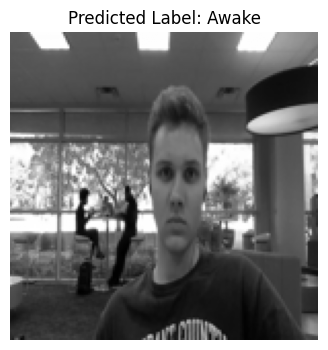

🖼️ Predicted Label: Awake


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan150_150_dynamic.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_11_frame_10201.jpg").convert("L")  # Convert to grayscale
image = image.resize((150, 150))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 150 * 150)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")


In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized dynamic model
interpreter = tf.lite.Interpreter(model_path="kan150_150_dynamic.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 150 * 150).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.94%
⏱️ Total Inference Time for 3367 Images: 2523.76 ms
⏱️ Average Inference Time per Sample: 0.75 ms


In [ ]:
# Convert kan150_150_dynamic.tflite to a C array
with open("kan150_150_dynamic.tflite", "rb") as f:
    tflite_model = f.read()

def convert_to_c_array(model_data, var_name="model_tflite"):
    c_code = f"unsigned char {var_name}[] = {{\n"
    hex_array = [f"0x{b:02x}" for b in model_data]
    for i in range(0, len(hex_array), 12):
        c_code += "    " + ", ".join(hex_array[i:i+12]) + ",\n"
    c_code += "};\n"
    c_code += f"unsigned int {var_name}_len = {len(model_data)};\n"
    return c_code

c_code = convert_to_c_array(tflite_model, "kan150_150_dynamic")
with open("kan150_150_dynamic.cc", "w") as f:
    f.write(c_code)

print("✅ Converted kan150_150_dynamic.tflite to C array and saved as kan150_150_dynamic.cc")


✅ Converted kan150_150_dynamic.tflite to C array and saved as kan150_150_dynamic.cc


In [ ]:
# Convert kan150_150_dynamic.tflite to a C array using xxd
os.system("xxd -i kan150_150_dynamic.tflite > kan150_150_dynamic.cc")

# Replace variable names in the generated C file
replace_text = "kan150_150_dynamic_tflite"
os.system(f"sed -i 's/{replace_text}/g_model/g' kan150_150_dynamic.cc")

# Print the generated C source file
os.system("cat kan150_150_dynamic.cc")

print("✅ Converted kan150_150_dynamic.tflite to C array and saved as kan150_150_dynamic.cc")

✅ Converted kan150_150_dynamic.tflite to C array and saved as kan150_150_dynamic.cc


In [ ]:
# Print the C source file
!cat kan150_150_dynamic.cc

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  0xb8, 0xe2, 0xe3, 0x3b, 0x2d, 0xef, 0xa2, 0xbb, 0x38, 0xbc, 0x91, 0x3c,
  0x21, 0x42, 0xcb, 0x3c, 0x41, 0x2d, 0x59, 0xba, 0x5e, 0x41, 0x78, 0x3c,
  0x4c, 0x88, 0xed, 0x3c, 0x5c, 0xc1, 0xd7, 0x3c, 0x49, 0x88, 0x57, 0x3b,
  0x88, 0x7b, 0xfc, 0xbb, 0x0a, 0xcd, 0x91, 0x3b, 0x18, 0xc4, 0xe1, 0x3c,
  0xcf, 0xa6, 0x50, 0x3c, 0x69, 0x0d, 0x77, 0x3c, 0xcd, 0xea, 0x8c, 0xbc,
  0x60, 0x7c, 0xad, 0xbb, 0x0b, 0x4b, 0xc0, 0x3b, 0xf3, 0x67, 0x64, 0x3a,
  0xd2, 0x4d, 0x3f, 0xbb, 0x19, 0xd3, 0xdc, 0x3c, 0x9d, 0x0b, 0xd6, 0xbc,
  0xd3, 0xd4, 0x48, 0xbc, 0xe6, 0x75, 0x4a, 0xbc, 0xe9, 0x64, 0x0d, 0x3d,
  0x12, 0x93, 0x34, 0x3c, 0x24, 0xb7, 0x8e, 0x3c, 0xe7, 0xbb, 0xae, 0x3a,
  0xb9, 0xae, 0x81, 0xbc, 0x7c, 0x30, 0x4e, 0xbd, 0x43, 0x61, 0x56, 0x3c,
  0x80, 0x65, 0x51, 0x3b, 0xee, 0xee, 0xbe, 0xbb, 0x7d, 0x99, 0x88, 0xbb,
  0x6f, 0x56, 0x92, 0x3c, 0x74, 0xc2, 0x05, 0x3d, 0xcf, 0xf8, 0xd0, 0x3c,
  0xcf, 0x0d, 0xd9, 0x3c, 0x0f, 0x

# **KAN_image_size_128_128**

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt
# --- Load and Process New Grayscale Dataset ---
directory = "/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris"
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 150

# Load dataset in grayscale mode
train_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.3, subset='training'
)
test_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.2, subset='validation'
)
valid_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.1, subset='validation'
)

# Convert dataset into NumPy arrays
def dataset_to_numpy(dataset):
    images, labels = [], []
    for batch in dataset:
        batch_images, batch_labels = batch
        images.extend(batch_images.numpy() / 255.0)  # Normalize
        labels.extend(batch_labels.numpy())
    return np.array(images), np.array(labels)

train_images, train_labels = dataset_to_numpy(train_ds)
test_images, test_labels = dataset_to_numpy(test_ds)
valid_images, valid_labels = dataset_to_numpy(valid_ds)

# Flatten images (150x150 → 22500 features)
train_images = train_images.reshape((-1, 128 * 128)).astype('float32')
test_images = test_images.reshape((-1, 128 * 128)).astype('float32')
valid_images = valid_images.reshape((-1, 128 * 128)).astype('float32')

Found 16839 files belonging to 2 classes.
Using 11788 files for training.
Found 16839 files belonging to 2 classes.
Using 3367 files for validation.
Found 16839 files belonging to 2 classes.
Using 1683 files for validation.



🚀 Building FastKAN with layers: [16384, 5, 2]
🔹 Initialized Radial Basis Function with 2 grids between [-1, 1]
✅ Initialized FastKANLayer: 16384 → 5 | Base Activation: swish
🔹 Initialized Radial Basis Function with 2 grids between [-1, 1]
✅ Initialized FastKANLayer: 5 → 2 | Base Activation: swish

🚀 Epoch 1/20
✅ Training Accuracy: 0.6689 | Validation Accuracy: 0.6589 | Training Loss: 0.7518 | Validation Loss: 0.6540

🚀 Epoch 2/20
✅ Training Accuracy: 0.7503 | Validation Accuracy: 0.7499 | Training Loss: 0.5371 | Validation Loss: 0.5009

🚀 Epoch 3/20
✅ Training Accuracy: 0.9940 | Validation Accuracy: 0.9958 | Training Loss: 0.2669 | Validation Loss: 0.1458

🚀 Epoch 4/20
✅ Training Accuracy: 0.9978 | Validation Accuracy: 0.9982 | Training Loss: 0.1169 | Validation Loss: 0.0919

🚀 Epoch 5/20
✅ Training Accuracy: 0.9989 | Validation Accuracy: 0.9982 | Training Loss: 0.0791 | Validation Loss: 0.0683

🚀 Epoch 6/20
✅ Training Accuracy: 0.9989 | Validation Accuracy: 0.9982 | Training Loss: 0.

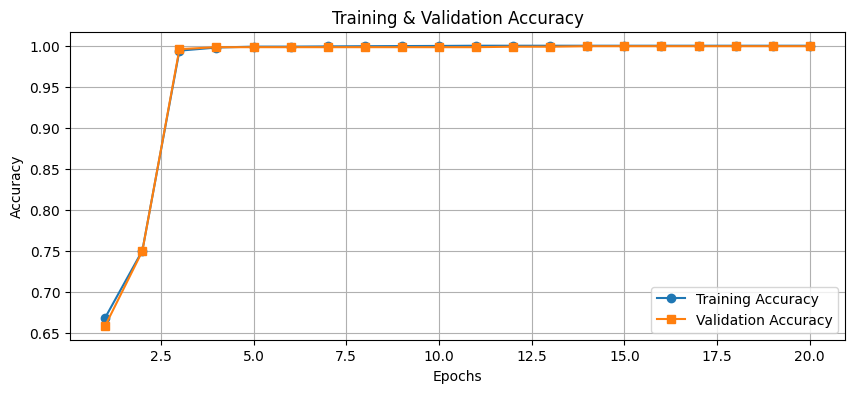

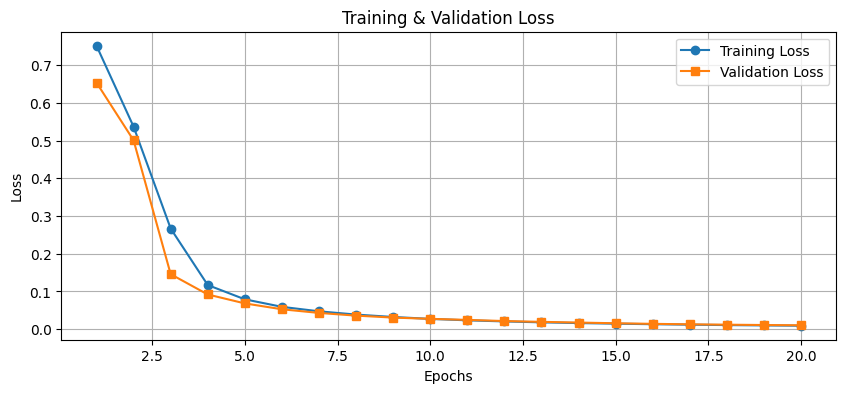

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt

# Define FastKAN model with modified architecture
class RadialBasisFunction(layers.Layer):
    def __init__(self, grid_min, grid_max, num_grids, **kwargs):
        super(RadialBasisFunction, self).__init__(**kwargs)
        self.grid = tf.cast(tf.linspace(grid_min, grid_max, num_grids), dtype=tf.float32)
        self.denominator = tf.cast((grid_max - grid_min) / num_grids, dtype=tf.float32)
        print(f"🔹 Initialized Radial Basis Function with {num_grids} grids between [{grid_min}, {grid_max}]")

    def call(self, x):
        return tf.exp(-((x[..., None] - self.grid) / self.denominator) ** 2)


class FastKANLayer(layers.Layer):
    def __init__(self, input_dim, output_dim, grid_min, grid_max, num_grids, use_base_update, base_activation):
        super(FastKANLayer, self).__init__()
        self.norm = layers.LayerNormalization(axis=-1)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = layers.Dense(output_dim)
        self.use_base_update = use_base_update
        self.base_activation_name = base_activation.__name__ if callable(base_activation) else "None"

        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = layers.Dense(output_dim)

        print(f"✅ Initialized FastKANLayer: {input_dim} → {output_dim} | Base Activation: {self.base_activation_name}")

    def call(self, x):
        x_norm = self.norm(x)
        spline_basis = self.rbf(x_norm)
        spline_basis_flat = tf.reshape(spline_basis, [tf.shape(spline_basis)[0], -1])
        ret = self.spline_linear(spline_basis_flat)

        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base

        return ret


class FastKAN(tf.keras.Model):
    def __init__(self, layers_hidden, grid_min=-1, grid_max=1, num_grids=2, use_base_update=False, base_activation=tf.nn.silu):
        super(FastKAN, self).__init__()
        self.layers_list = []
        print(f"\n🚀 Building FastKAN with layers: {layers_hidden}")
        for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:]):
            self.layers_list.append(FastKANLayer(in_dim, out_dim, grid_min, grid_max, num_grids, use_base_update, base_activation))

    def call(self, inputs):
        x = inputs
        for layer in self.layers_list:
            x = layer(x)
        return x

# Define optimized KAN model
def create_kan():
    return FastKAN([128 * 128, 5, 2], grid_min=-1, grid_max=1, num_grids=2, use_base_update=True, base_activation=tf.nn.silu)

model = create_kan()

# Define optimizer and loss function
optimizer = optimizers.Adam(learning_rate=1e-3)
loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)
accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

# Model Training Parameters
EPOCHS = 20
BATCH_SIZE = 256

# Define function to compute validation loss
def compute_loss(images, labels):
    logits = model(images)
    return loss_fn(labels, logits).numpy()

# Function to compute accuracy
def compute_accuracy(images, labels):
    logits = model(images)
    predictions = tf.argmax(logits, axis=1)
    correct = tf.cast(tf.equal(predictions, labels), dtype=tf.float32)
    return tf.reduce_mean(correct)

# Training Loop
train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], []

for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")

    epoch_train_loss = 0
    num_batches = 0

    # Training loop
    for step in range(0, len(train_images), BATCH_SIZE):
        x_batch_train = train_images[step:step + BATCH_SIZE]
        y_batch_train = train_labels[step:step + BATCH_SIZE]

        with tf.GradientTape() as tape:
            logits = model(x_batch_train)
            loss_value = loss_fn(y_batch_train, logits)

        grads = tape.gradient(loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

        epoch_train_loss += loss_value.numpy()
        num_batches += 1

    # Compute average training loss
    avg_train_loss = epoch_train_loss / num_batches
    train_loss_list.append(avg_train_loss)

    # Compute accuracy
    train_acc = compute_accuracy(train_images, train_labels).numpy()
    val_acc = compute_accuracy(valid_images, valid_labels).numpy()

    # Compute validation loss
    val_loss = compute_loss(valid_images, valid_labels)
    val_loss_list.append(val_loss)

    print(f"✅ Training Accuracy: {train_acc:.4f} | Validation Accuracy: {val_acc:.4f} | Training Loss: {avg_train_loss:.4f} | Validation Loss: {val_loss:.4f}")

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

# Print Activation Function Parameters After Training
print("\n🔍 **Trained Activation Function Parameters:**")
for layer in model.layers_list:
    if isinstance(layer, FastKANLayer) and layer.use_base_update:
        print(f"Layer: {layer.spline_linear.name}")
        print(f"  Activation Function: {layer.base_activation_name}")
        print(f"  Base Linear Weights Shape: {layer.base_linear.weights[0].shape}")
        print(f"  Base Linear Bias Shape: {layer.base_linear.weights[1].shape}\n")

model.save("kan128_128.keras")

# Plot Accuracy Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_acc_list, label="Training Accuracy", marker='o')
plt.plot(range(1, EPOCHS+1), val_acc_list, label="Validation Accuracy", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.grid()
plt.show()

# Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_loss_list, label="Training Loss", marker='o')
plt.plot(range(1, EPOCHS+1), val_loss_list, label="Validation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.grid()
plt.show()


In [ ]:
# Print train, validation, and test accuracy
train_acc = compute_accuracy(train_images, train_labels).numpy()
val_acc = compute_accuracy(valid_images, valid_labels).numpy()
test_acc = compute_accuracy(test_images, test_labels).numpy()

print(f"✅ Training Accuracy: {train_acc:.4f}")
print(f"✅ Validation Accuracy: {val_acc:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")


✅ Training Accuracy: 1.0000
✅ Validation Accuracy: 0.9994
✅ Test Accuracy: 0.9991


In [ ]:
# Print the number of trainable and non-trainable parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_variables])
non_trainable_params = total_params - trainable_params

print(f"📌 Total Parameters: {total_params}")
print(f"🔧 Trainable Parameters: {trainable_params}")
print(f"🚫 Non-Trainable Parameters: {non_trainable_params}")


📌 Total Parameters: 278582
🔧 Trainable Parameters: 278582
🚫 Non-Trainable Parameters: 0


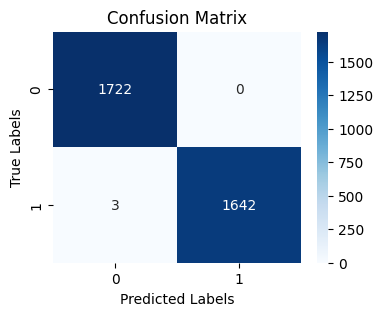

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute predictions
test_predictions = model(test_images)
test_pred_labels = tf.argmax(test_predictions, axis=1).numpy()

# Generate confusion matrix
cm = confusion_matrix(test_labels, test_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt

# Define representative dataset function for integer quantization
def representative_dataset():
    for i in range(100):  # Using a subset of training data
        yield [train_images[i: i + 1]]

# Ensure all variables are frozen before conversion
tf.lite.TFLiteConverter.experimental_new_converter = True

# Export the model to SavedModel format with a signature function
def serving_fn(inputs):
    return {"outputs": model(inputs)}

signature = tf.function(serving_fn).get_concrete_function(
    tf.TensorSpec(shape=[None, 128 * 128], dtype=tf.float32)
)

# Save model in Keras format instead of SavedModel
model.save("kan128_128.keras")

# Convert the model to TFLite format with different quantization methods
# 1. Default Quantization (Dynamic Range)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
dynamic_tflite_model = converter.convert()
with open("kan128_128_dynamic.tflite", "wb") as f:
    f.write(dynamic_tflite_model)
print("✅ Dynamic range quantized model saved as kan128_128_dynamic.tflite")

# 2. Float16 Quantization
converter.target_spec.supported_types = [tf.float16]
float16_tflite_model = converter.convert()
with open("kan128_128_float16.tflite", "wb") as f:
    f.write(float16_tflite_model)
print("✅ Float16 quantized model saved as kan128_128_float16.tflite")

# 3. Full Integer Quantization (with representative dataset)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
integer_tflite_model = converter.convert()
with open("kan128_128_integer.tflite", "wb") as f:
    f.write(integer_tflite_model)
print("✅ Full integer quantized model saved as kan128_128_integer.tflite")

# 4. Weight Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.OPTIMIZE_FOR_SIZE]
weight_tflite_model = converter.convert()
with open("kan128_128_weight.tflite", "wb") as f:
    f.write(weight_tflite_model)
print("✅ Weight quantized model saved as kan128_128_weight.tflite")


Saved artifact at '/tmp/tmp66eisntk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 16384), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138844681353360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138800079035792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849839864080: TensorSpec(shape=(2,), dtype=tf.float32, name=None)
  138803277887632: TensorSpec(shape=(), dtype=tf.float32, name=None)
  138800079039440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138800079038096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138821662835536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849839860240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138803277881488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849839870992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138844681352784: TensorSpec(sh

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Full integer quantized model saved as kan128_128_integer.tflite
Saved artifact at '/tmp/tmp013hn02i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 16384), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138844681353360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138800079035792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849839864080: TensorSpec(shape=(2,), dtype=tf.float32, name=None)
  138803277887632: TensorSpec(shape=(), dtype=tf.float32, name=None)
  138800079039440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138800079038096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138821662835536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849839860240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138803277881488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849839870992: TensorSpec(shape=

✅ Weight quantized model saved as kan128_128_weight.tflite


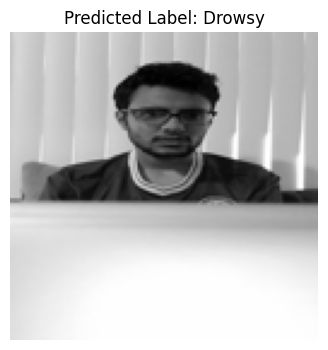

🖼️ Predicted Label: 1


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt
from PIL import Image

# Define representative dataset function for integer quantization
def representative_dataset():
    for i in range(100):  # Using a subset of training data
        yield [train_images[i: i + 1]]

# Ensure all variables are frozen before conversion
tf.lite.TFLiteConverter.experimental_new_converter = True

# Export the model to SavedModel format with a signature function
def serving_fn(inputs):
    return {"outputs": model(inputs)}

signature = tf.function(serving_fn).get_concrete_function(
    tf.TensorSpec(shape=[None, 128 * 128], dtype=tf.float32)
)


# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan128_128_integer.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_13_frame_349.jpg").convert("L")  # Convert to grayscale
image = image.resize((128, 128))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 128 * 128)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.int8))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label}")



In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized dynamic model
interpreter = tf.lite.Interpreter(model_path="kan128_128_integer.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 128 * 128).astype(np.int8)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()
    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 48.86%
⏱️ Total Inference Time for 3367 Images: 2717.73 ms
⏱️ Average Inference Time per Sample: 0.81 ms


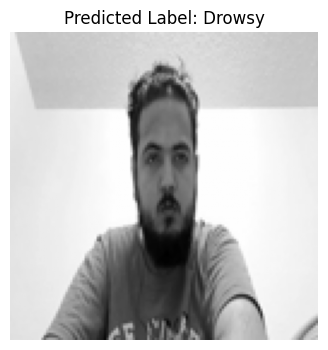

🖼️ Predicted Label: Drowsy


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan128_128_float16.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/drowsy/10_14_frame_15661.jpg").convert("L")  # Convert to grayscale
image = image.resize((128, 128))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 128 * 128)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")

In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized Float16 model
interpreter = tf.lite.Interpreter(model_path="kan128_128_float16.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 128* 128).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.91%
⏱️ Total Inference Time for 3367 Images: 2077.16 ms
⏱️ Average Inference Time per Sample: 0.62 ms


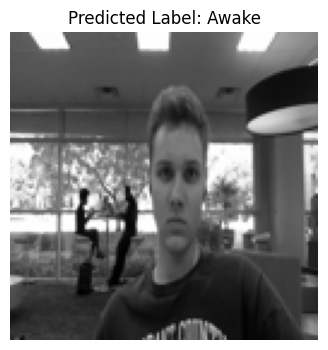

🖼️ Predicted Label: Awake


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan128_128_weight.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_11_frame_10201.jpg").convert("L")  # Convert to grayscale
image = image.resize((128, 128))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 128 * 128)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")


In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized Weight-Only model
interpreter = tf.lite.Interpreter(model_path="kan128_128_weight.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 128 * 128).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.91%
⏱️ Total Inference Time for 3367 Images: 1732.29 ms
⏱️ Average Inference Time per Sample: 0.51 ms


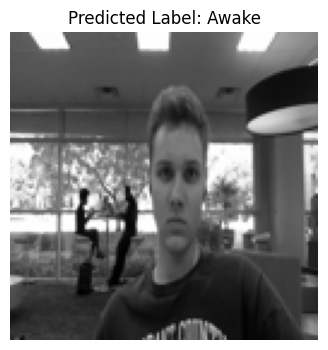

🖼️ Predicted Label: Awake


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan128_128_dynamic.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_11_frame_10201.jpg").convert("L")  # Convert to grayscale
image = image.resize((128, 128))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 128 * 128)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")


In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized dynamic model
interpreter = tf.lite.Interpreter(model_path="kan128_128_dynamic.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 128 * 128).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.91%
⏱️ Total Inference Time for 3367 Images: 1738.70 ms
⏱️ Average Inference Time per Sample: 0.52 ms


In [ ]:
# Convert kan150_150_dynamic.tflite to a C array
with open("kan128_128_dynamic.tflite", "rb") as f:
    tflite_model = f.read()

def convert_to_c_array(model_data, var_name="model_tflite128"):
    c_code = f"unsigned char {var_name}[] = {{\n"
    hex_array = [f"0x{b:02x}" for b in model_data]
    for i in range(0, len(hex_array), 12):
        c_code += "    " + ", ".join(hex_array[i:i+12]) + ",\n"
    c_code += "};\n"
    c_code += f"unsigned int {var_name}_len = {len(model_data)};\n"
    return c_code

c_code = convert_to_c_array(tflite_model, "kan128_128_dynamic")
with open("kan128_128_dynamic.cc", "w") as f:
    f.write(c_code)

print("✅ Converted kan128_128_dynamic.tflite to C array and saved as kan128_128_dynamic.cc")


✅ Converted kan128_128_dynamic.tflite to C array and saved as kan128_128_dynamic.cc


In [ ]:
# Print the C source file
!cat kan150_150_dynamic.cc

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  0xd7, 0x00, 0xa2, 0x3c, 0x61, 0xa9, 0x1a, 0x3d, 0x7e, 0x70, 0x73, 0x3d,
  0xca, 0x9e, 0x4c, 0xbb, 0x85, 0xf0, 0x3d, 0x3d, 0x56, 0xb8, 0x13, 0x3d,
  0xca, 0xf6, 0x56, 0x3c, 0x17, 0x97, 0x77, 0x3c, 0x5d, 0xc1, 0x0d, 0x3d,
  0xfe, 0x8c, 0xad, 0xb9, 0x5e, 0x60, 0x8a, 0x3b, 0x46, 0xa2, 0x85, 0x3c,
  0x01, 0xe8, 0x28, 0x3c, 0xb0, 0x4b, 0xcc, 0x3c, 0xad, 0xcd, 0xf4, 0x3c,
  0x65, 0x09, 0x10, 0xbc, 0x4b, 0x3e, 0x2f, 0xbc, 0x46, 0x89, 0xf8, 0xbc,
  0x13, 0x67, 0x7c, 0xbc, 0x9c, 0x8e, 0x13, 0xbc, 0x76, 0x82, 0x16, 0xbd,
  0x21, 0x47, 0x0b, 0xbd, 0xc3, 0x5e, 0xa8, 0x3b, 0x36, 0x22, 0x75, 0xbd,
  0x6f, 0x87, 0x65, 0xbc, 0x91, 0x9a, 0xf6, 0xbc, 0x8c, 0x5e, 0x4e, 0xbc,
  0x7d, 0x3f, 0x23, 0xbd, 0xcb, 0x46, 0x42, 0xbc, 0x2e, 0xc0, 0x89, 0xbc,
  0x24, 0x5e, 0x3d, 0xbd, 0x99, 0x42, 0xab, 0xbc, 0x49, 0x59, 0x6a, 0x3b,
  0x97, 0x6c, 0xb0, 0x3b, 0x29, 0xb6, 0x06, 0xbc, 0x56, 0x81, 0x96, 0xbc,
  0x00, 0x77, 0x9a, 0x3b, 0x98, 0x

# **KAN_image_size_64_64**

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt
# --- Load and Process New Grayscale Dataset ---
directory = "/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris"
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 150

# Load dataset in grayscale mode
train_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.3, subset='training'
)
test_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.2, subset='validation'
)
valid_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.1, subset='validation'
)

# Convert dataset into NumPy arrays
def dataset_to_numpy(dataset):
    images, labels = [], []
    for batch in dataset:
        batch_images, batch_labels = batch
        images.extend(batch_images.numpy() / 255.0)  # Normalize
        labels.extend(batch_labels.numpy())
    return np.array(images), np.array(labels)

train_images, train_labels = dataset_to_numpy(train_ds)
test_images, test_labels = dataset_to_numpy(test_ds)
valid_images, valid_labels = dataset_to_numpy(valid_ds)

# Flatten images (150x150 → 22500 features)
train_images = train_images.reshape((-1, 64 * 64)).astype('float32')
test_images = test_images.reshape((-1, 64* 64)).astype('float32')
valid_images = valid_images.reshape((-1, 64 * 64)).astype('float32')

Found 16839 files belonging to 2 classes.
Using 11788 files for training.
Found 16839 files belonging to 2 classes.
Using 3367 files for validation.
Found 16839 files belonging to 2 classes.
Using 1683 files for validation.



🚀 Building FastKAN with layers: [4096, 5, 2]
🔹 Initialized Radial Basis Function with 2 grids between [-1, 1]
✅ Initialized FastKANLayer: 4096 → 5 | Base Activation: swish
🔹 Initialized Radial Basis Function with 2 grids between [-1, 1]
✅ Initialized FastKANLayer: 5 → 2 | Base Activation: swish

🚀 Epoch 1/20
✅ Training Accuracy: 0.9157 | Validation Accuracy: 0.9127 | Training Loss: 0.6076 | Validation Loss: 0.4299

🚀 Epoch 2/20
✅ Training Accuracy: 0.9955 | Validation Accuracy: 0.9970 | Training Loss: 0.3106 | Validation Loss: 0.2460

🚀 Epoch 3/20
✅ Training Accuracy: 0.9969 | Validation Accuracy: 0.9958 | Training Loss: 0.2026 | Validation Loss: 0.1758

🚀 Epoch 4/20
✅ Training Accuracy: 0.9986 | Validation Accuracy: 0.9982 | Training Loss: 0.1432 | Validation Loss: 0.1214

🚀 Epoch 5/20
✅ Training Accuracy: 0.9988 | Validation Accuracy: 0.9976 | Training Loss: 0.1045 | Validation Loss: 0.0949

🚀 Epoch 6/20
✅ Training Accuracy: 0.9988 | Validation Accuracy: 0.9976 | Training Loss: 0.08

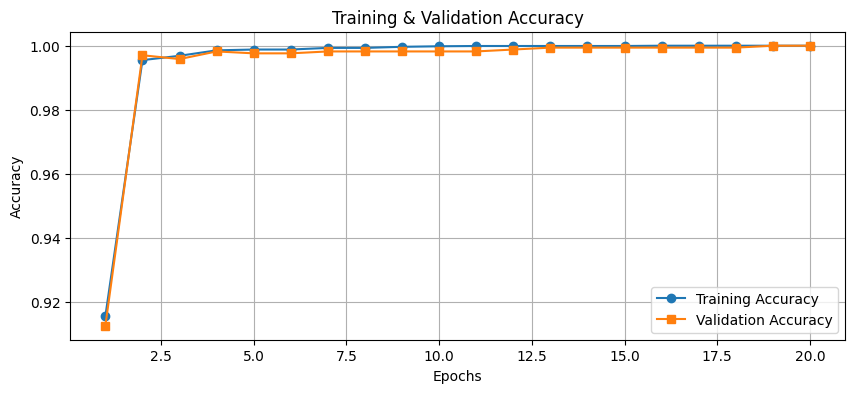

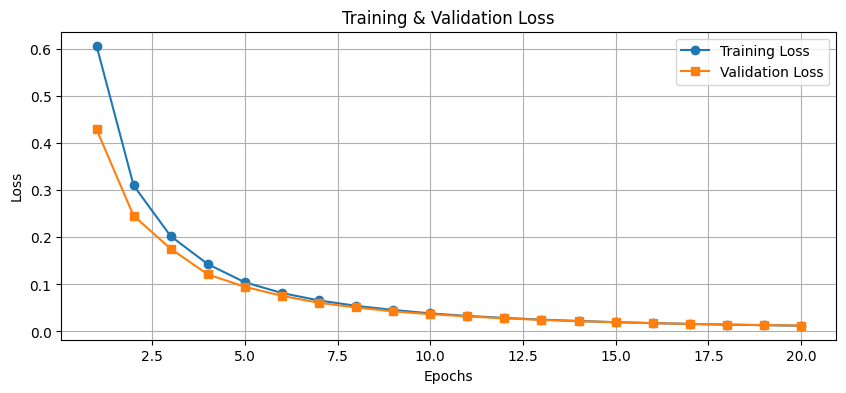

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt

# Define FastKAN model with modified architecture
class RadialBasisFunction(layers.Layer):
    def __init__(self, grid_min, grid_max, num_grids, **kwargs):
        super(RadialBasisFunction, self).__init__(**kwargs)
        self.grid = tf.cast(tf.linspace(grid_min, grid_max, num_grids), dtype=tf.float32)
        self.denominator = tf.cast((grid_max - grid_min) / num_grids, dtype=tf.float32)
        print(f"🔹 Initialized Radial Basis Function with {num_grids} grids between [{grid_min}, {grid_max}]")

    def call(self, x):
        return tf.exp(-((x[..., None] - self.grid) / self.denominator) ** 2)


class FastKANLayer(layers.Layer):
    def __init__(self, input_dim, output_dim, grid_min, grid_max, num_grids, use_base_update, base_activation):
        super(FastKANLayer, self).__init__()
        self.norm = layers.LayerNormalization(axis=-1)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = layers.Dense(output_dim)
        self.use_base_update = use_base_update
        self.base_activation_name = base_activation.__name__ if callable(base_activation) else "None"

        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = layers.Dense(output_dim)

        print(f"✅ Initialized FastKANLayer: {input_dim} → {output_dim} | Base Activation: {self.base_activation_name}")

    def call(self, x):
        x_norm = self.norm(x)
        spline_basis = self.rbf(x_norm)
        spline_basis_flat = tf.reshape(spline_basis, [tf.shape(spline_basis)[0], -1])
        ret = self.spline_linear(spline_basis_flat)

        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base

        return ret


class FastKAN(tf.keras.Model):
    def __init__(self, layers_hidden, grid_min=-1, grid_max=1, num_grids=2, use_base_update=False, base_activation=tf.nn.silu):
        super(FastKAN, self).__init__()
        self.layers_list = []
        print(f"\n🚀 Building FastKAN with layers: {layers_hidden}")
        for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:]):
            self.layers_list.append(FastKANLayer(in_dim, out_dim, grid_min, grid_max, num_grids, use_base_update, base_activation))

    def call(self, inputs):
        x = inputs
        for layer in self.layers_list:
            x = layer(x)
        return x

# Define optimized KAN model
def create_kan():
    return FastKAN([64 * 64, 5, 2], grid_min=-1, grid_max=1, num_grids=2, use_base_update=True, base_activation=tf.nn.silu)

model = create_kan()

# Define optimizer and loss function
optimizer = optimizers.Adam(learning_rate=1e-3)
loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)
accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

# Model Training Parameters
EPOCHS = 20
BATCH_SIZE = 256

# Define function to compute validation loss
def compute_loss(images, labels):
    logits = model(images)
    return loss_fn(labels, logits).numpy()

# Function to compute accuracy
def compute_accuracy(images, labels):
    logits = model(images)
    predictions = tf.argmax(logits, axis=1)
    correct = tf.cast(tf.equal(predictions, labels), dtype=tf.float32)
    return tf.reduce_mean(correct)

# Training Loop
train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], []

for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")

    epoch_train_loss = 0
    num_batches = 0

    # Training loop
    for step in range(0, len(train_images), BATCH_SIZE):
        x_batch_train = train_images[step:step + BATCH_SIZE]
        y_batch_train = train_labels[step:step + BATCH_SIZE]

        with tf.GradientTape() as tape:
            logits = model(x_batch_train)
            loss_value = loss_fn(y_batch_train, logits)

        grads = tape.gradient(loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

        epoch_train_loss += loss_value.numpy()
        num_batches += 1

    # Compute average training loss
    avg_train_loss = epoch_train_loss / num_batches
    train_loss_list.append(avg_train_loss)

    # Compute accuracy
    train_acc = compute_accuracy(train_images, train_labels).numpy()
    val_acc = compute_accuracy(valid_images, valid_labels).numpy()

    # Compute validation loss
    val_loss = compute_loss(valid_images, valid_labels)
    val_loss_list.append(val_loss)

    print(f"✅ Training Accuracy: {train_acc:.4f} | Validation Accuracy: {val_acc:.4f} | Training Loss: {avg_train_loss:.4f} | Validation Loss: {val_loss:.4f}")

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

# Print Activation Function Parameters After Training
print("\n🔍 **Trained Activation Function Parameters:**")
for layer in model.layers_list:
    if isinstance(layer, FastKANLayer) and layer.use_base_update:
        print(f"Layer: {layer.spline_linear.name}")
        print(f"  Activation Function: {layer.base_activation_name}")
        print(f"  Base Linear Weights Shape: {layer.base_linear.weights[0].shape}")
        print(f"  Base Linear Bias Shape: {layer.base_linear.weights[1].shape}\n")

model.save("kan64_64.keras")

# Plot Accuracy Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_acc_list, label="Training Accuracy", marker='o')
plt.plot(range(1, EPOCHS+1), val_acc_list, label="Validation Accuracy", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.grid()
plt.show()

# Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_loss_list, label="Training Loss", marker='o')
plt.plot(range(1, EPOCHS+1), val_loss_list, label="Validation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.grid()
plt.show()


In [ ]:
# Print train, validation, and test accuracy
train_acc = compute_accuracy(train_images, train_labels).numpy()
val_acc = compute_accuracy(valid_images, valid_labels).numpy()
test_acc = compute_accuracy(test_images, test_labels).numpy()

print(f"✅ Training Accuracy: {train_acc:.4f}")
print(f"✅ Validation Accuracy: {val_acc:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")


✅ Training Accuracy: 1.0000
✅ Validation Accuracy: 1.0000
✅ Test Accuracy: 0.9997


In [ ]:
# Print the number of trainable and non-trainable parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_variables])
non_trainable_params = total_params - trainable_params

print(f"📌 Total Parameters: {total_params}")
print(f"🔧 Trainable Parameters: {trainable_params}")
print(f"🚫 Non-Trainable Parameters: {non_trainable_params}")


📌 Total Parameters: 69686
🔧 Trainable Parameters: 69686
🚫 Non-Trainable Parameters: 0


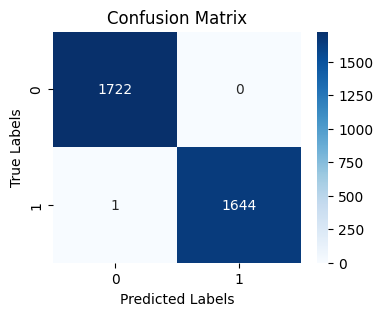

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute predictions
test_predictions = model(test_images)
test_pred_labels = tf.argmax(test_predictions, axis=1).numpy()

# Generate confusion matrix
cm = confusion_matrix(test_labels, test_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt

# Define representative dataset function for integer quantization
def representative_dataset():
    for i in range(100):  # Using a subset of training data
        yield [train_images[i: i + 1]]

# Ensure all variables are frozen before conversion
tf.lite.TFLiteConverter.experimental_new_converter = True

# Export the model to SavedModel format with a signature function
def serving_fn(inputs):
    return {"outputs": model(inputs)}

signature = tf.function(serving_fn).get_concrete_function(
    tf.TensorSpec(shape=[None, 64 * 64], dtype=tf.float32)
)

# Save model in Keras format instead of SavedModel
model.save("kan64_64.keras")

# Convert the model to TFLite format with different quantization methods
# 1. Default Quantization (Dynamic Range)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
dynamic_tflite_model = converter.convert()
with open("kan64_64_dynamic.tflite", "wb") as f:
    f.write(dynamic_tflite_model)
print("✅ Dynamic range quantized model saved as kan64_64_dynamic.tflite")

# 2. Float16 Quantization
converter.target_spec.supported_types = [tf.float16]
float16_tflite_model = converter.convert()
with open("kan64_64_float16.tflite", "wb") as f:
    f.write(float16_tflite_model)
print("✅ Float16 quantized model saved as kan64_64_float16.tflite")

# 3. Full Integer Quantization (with representative dataset)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
integer_tflite_model = converter.convert()
with open("kan64_64_integer.tflite", "wb") as f:
    f.write(integer_tflite_model)
print("✅ Full integer quantized model saved as kan64_64_integer.tflite")

# 4. Weight Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.OPTIMIZE_FOR_SIZE]
weight_tflite_model = converter.convert()
with open("kan64_64_weight.tflite", "wb") as f:
    f.write(weight_tflite_model)
print("✅ Weight quantized model saved as kan64_64_weight.tflite")


Saved artifact at '/tmp/tmpqms_fyvv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4096), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136745358873360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358873936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358871632: TensorSpec(shape=(2,), dtype=tf.float32, name=None)
  136745358875280: TensorSpec(shape=(), dtype=tf.float32, name=None)
  136745358871248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358875856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358876624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358876432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358877200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358876240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358875664: TensorSpec(sha

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Full integer quantized model saved as kan64_64_integer.tflite
Saved artifact at '/tmp/tmpqusqemtk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4096), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136745358873360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358873936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358871632: TensorSpec(shape=(2,), dtype=tf.float32, name=None)
  136745358875280: TensorSpec(shape=(), dtype=tf.float32, name=None)
  136745358871248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358875856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358876624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358876432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358877200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136745358876240: TensorSpec(shape=(),

✅ Weight quantized model saved as kan64_64_weight.tflite


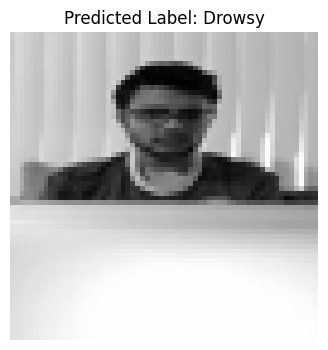

🖼️ Predicted Label: 1


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt
from PIL import Image

# Define representative dataset function for integer quantization
def representative_dataset():
    for i in range(100):  # Using a subset of training data
        yield [train_images[i: i + 1]]

# Ensure all variables are frozen before conversion
tf.lite.TFLiteConverter.experimental_new_converter = True

# Export the model to SavedModel format with a signature function
def serving_fn(inputs):
    return {"outputs": model(inputs)}

signature = tf.function(serving_fn).get_concrete_function(
    tf.TensorSpec(shape=[None, 64 * 64], dtype=tf.float32)
)


# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan64_64_integer.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_13_frame_349.jpg").convert("L")  # Convert to grayscale
image = image.resize((64, 64))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 64 * 64)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.int8))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label}")



In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized dynamic model
interpreter = tf.lite.Interpreter(model_path="kan64_64_integer.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 64 * 64).astype(np.int8)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()
    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 48.86%
⏱️ Total Inference Time for 3367 Images: 695.97 ms
⏱️ Average Inference Time per Sample: 0.21 ms


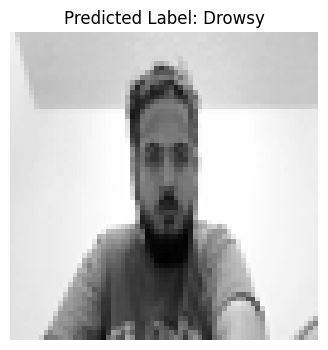

🖼️ Predicted Label: Drowsy


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan64_64_float16.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/drowsy/10_14_frame_15661.jpg").convert("L")  # Convert to grayscale
image = image.resize((64, 64))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 64 * 64)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")

In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized Float16 model
interpreter = tf.lite.Interpreter(model_path="kan64_64_float16.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 64* 64).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.97%
⏱️ Total Inference Time for 3367 Images: 499.62 ms
⏱️ Average Inference Time per Sample: 0.15 ms


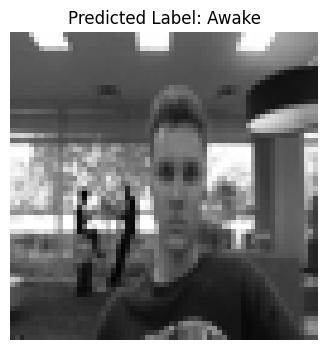

🖼️ Predicted Label: Awake


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan64_64_weight.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_11_frame_10201.jpg").convert("L")  # Convert to grayscale
image = image.resize((64, 64))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 64 * 64)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")


In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized Weight-Only model
interpreter = tf.lite.Interpreter(model_path="kan64_64_weight.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 64 * 64).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.97%
⏱️ Total Inference Time for 3367 Images: 407.04 ms
⏱️ Average Inference Time per Sample: 0.12 ms


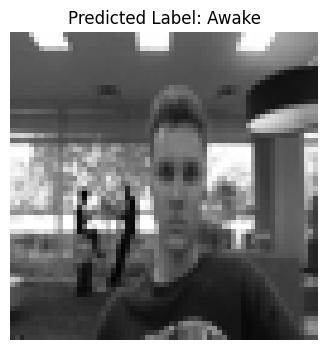

🖼️ Predicted Label: Awake


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan64_64_dynamic.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_11_frame_10201.jpg").convert("L")  # Convert to grayscale
image = image.resize((64, 64))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 64 * 64)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")


In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized dynamic model
interpreter = tf.lite.Interpreter(model_path="kan64_64_dynamic.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 64 * 64).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.97%
⏱️ Total Inference Time for 3367 Images: 434.86 ms
⏱️ Average Inference Time per Sample: 0.13 ms


In [ ]:
# Convert kan150_150_dynamic.tflite to a C array
with open("kan64_64_dynamic.tflite", "rb") as f:
    tflite_model = f.read()

def convert_to_c_array(model_data, var_name="model_tflite64"):
    c_code = f"unsigned char {var_name}[] = {{\n"
    hex_array = [f"0x{b:02x}" for b in model_data]
    for i in range(0, len(hex_array), 12):
        c_code += "    " + ", ".join(hex_array[i:i+12]) + ",\n"
    c_code += "};\n"
    c_code += f"unsigned int {var_name}_len = {len(model_data)};\n"
    return c_code

c_code = convert_to_c_array(tflite_model, "kan64_64_dynamic")
with open("kan64_64_dynamic.cc", "w") as f:
    f.write(c_code)

print("✅ Converted kan64_64_dynamic.tflite to C array and saved as kan64_64_dynamic.cc")


✅ Converted kan64_64_dynamic.tflite to C array and saved as kan64_64_dynamic.cc


In [ ]:
# Print the C source file
!cat kan64_64_dynamic.cc

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
    0xda, 0xe6, 0x0e, 0x12, 0x19, 0xcb, 0x1c, 0xcf, 0xe0, 0x04, 0xee, 0x17,
    0x10, 0xca, 0xd3, 0xdc, 0xff, 0xd8, 0x0b, 0xf8, 0xe1, 0xc9, 0xd4, 0xeb,
    0x03, 0x24, 0xf7, 0x06, 0x07, 0xd2, 0x16, 0xe5, 0x11, 0xe1, 0xf6, 0xe4,
    0xe2, 0xff, 0xe6, 0xd7, 0x0b, 0xff, 0x0d, 0xc8, 0xff, 0xcd, 0xcd, 0xd2,
    0x14, 0xef, 0xd4, 0xde, 0x0a, 0x28, 0x0c, 0xdc, 0x08, 0xd9, 0xf5, 0x32,
    0xd3, 0xf9, 0xd2, 0x13, 0xcd, 0xe8, 0xcd, 0x26, 0xde, 0xf9, 0x1f, 0x24,
    0x18, 0xe8, 0x1f, 0x0f, 0x1f, 0xf4, 0xfc, 0xf9, 0xda, 0x13, 0xf7, 0x1c,
    0x27, 0x26, 0x16, 0x15, 0xd6, 0x06, 0xf6, 0x0e, 0xd1, 0xe6, 0xc5, 0x25,
    0x0f, 0xe1, 0x16, 0xf6, 0x08, 0xe8, 0xc5, 0xe2, 0xef, 0xde, 0x04, 0x29,
    0xaf, 0x20, 0xfe, 0xec, 0xa8, 0x44, 0xe6, 0x2b, 0x00, 0xf8, 0x13, 0xe4,
    0x0c, 0x0c, 0xe6, 0x0b, 0xd3, 0x00, 0xdb, 0xf7, 0xe0, 0x29, 0xba, 0xfe,
    0x1a, 0xe9, 0xb8, 0x10, 0x1a, 0x21, 0xe7, 0xdd, 0xdb, 0xe5, 0xbd, 0xe4,
    0xdd, 

# **KAN_image_size_32_32**

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt
# --- Load and Process New Grayscale Dataset ---
directory = "/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris"
IMAGE_SIZE = (32, 32)
BATCH_SIZE = 150

# Load dataset in grayscale mode
train_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.3, subset='training'
)
test_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.2, subset='validation'
)
valid_ds = keras.utils.image_dataset_from_directory(
    directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, color_mode="grayscale", shuffle=True, seed=42, validation_split=0.1, subset='validation'
)

# Convert dataset into NumPy arrays
def dataset_to_numpy(dataset):
    images, labels = [], []
    for batch in dataset:
        batch_images, batch_labels = batch
        images.extend(batch_images.numpy() / 255.0)  # Normalize
        labels.extend(batch_labels.numpy())
    return np.array(images), np.array(labels)

train_images, train_labels = dataset_to_numpy(train_ds)
test_images, test_labels = dataset_to_numpy(test_ds)
valid_images, valid_labels = dataset_to_numpy(valid_ds)

# Flatten images (150x150 → 22500 features)
train_images = train_images.reshape((-1, 32 * 32)).astype('float32')
test_images = test_images.reshape((-1, 32 * 32)).astype('float32')
valid_images = valid_images.reshape((-1, 32 * 32)).astype('float32')

Found 16839 files belonging to 2 classes.
Using 11788 files for training.
Found 16839 files belonging to 2 classes.
Using 3367 files for validation.
Found 16839 files belonging to 2 classes.
Using 1683 files for validation.



🚀 Building FastKAN with layers: [1024, 5, 2]
🔹 Initialized Radial Basis Function with 2 grids between [-1, 1]
✅ Initialized FastKANLayer: 1024 → 5 | Base Activation: swish
🔹 Initialized Radial Basis Function with 2 grids between [-1, 1]
✅ Initialized FastKANLayer: 5 → 2 | Base Activation: swish

🚀 Epoch 1/20
✅ Training Accuracy: 0.9695 | Validation Accuracy: 0.9733 | Training Loss: 0.3816 | Validation Loss: 0.2012

🚀 Epoch 2/20
✅ Training Accuracy: 0.9895 | Validation Accuracy: 0.9857 | Training Loss: 0.1334 | Validation Loss: 0.0949

🚀 Epoch 3/20
✅ Training Accuracy: 0.9973 | Validation Accuracy: 0.9982 | Training Loss: 0.0684 | Validation Loss: 0.0485

🚀 Epoch 4/20
✅ Training Accuracy: 0.9982 | Validation Accuracy: 0.9988 | Training Loss: 0.0405 | Validation Loss: 0.0311

🚀 Epoch 5/20
✅ Training Accuracy: 0.9986 | Validation Accuracy: 0.9988 | Training Loss: 0.0266 | Validation Loss: 0.0216

🚀 Epoch 6/20
✅ Training Accuracy: 0.9987 | Validation Accuracy: 0.9994 | Training Loss: 0.01

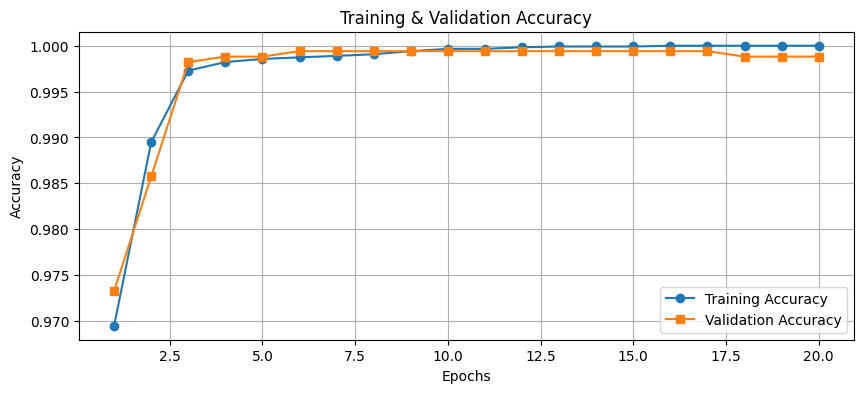

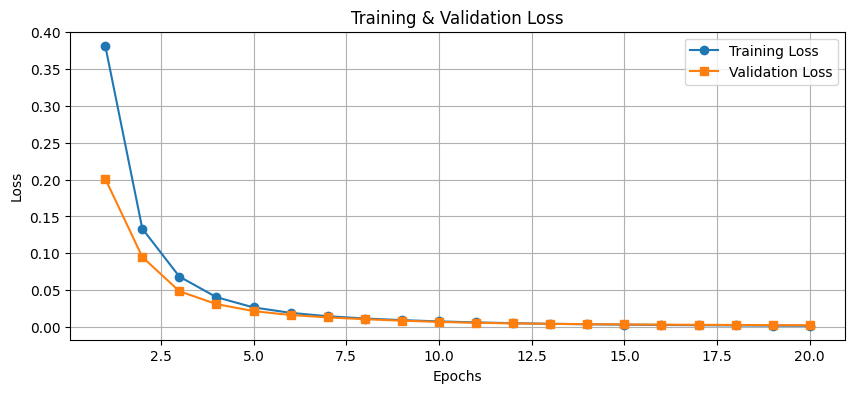

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt

# Define FastKAN model with modified architecture
class RadialBasisFunction(layers.Layer):
    def __init__(self, grid_min, grid_max, num_grids, **kwargs):
        super(RadialBasisFunction, self).__init__(**kwargs)
        self.grid = tf.cast(tf.linspace(grid_min, grid_max, num_grids), dtype=tf.float32)
        self.denominator = tf.cast((grid_max - grid_min) / num_grids, dtype=tf.float32)
        print(f"🔹 Initialized Radial Basis Function with {num_grids} grids between [{grid_min}, {grid_max}]")

    def call(self, x):
        return tf.exp(-((x[..., None] - self.grid) / self.denominator) ** 2)


class FastKANLayer(layers.Layer):
    def __init__(self, input_dim, output_dim, grid_min, grid_max, num_grids, use_base_update, base_activation):
        super(FastKANLayer, self).__init__()
        self.norm = layers.LayerNormalization(axis=-1)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = layers.Dense(output_dim)
        self.use_base_update = use_base_update
        self.base_activation_name = base_activation.__name__ if callable(base_activation) else "None"

        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = layers.Dense(output_dim)

        print(f"✅ Initialized FastKANLayer: {input_dim} → {output_dim} | Base Activation: {self.base_activation_name}")

    def call(self, x):
        x_norm = self.norm(x)
        spline_basis = self.rbf(x_norm)
        spline_basis_flat = tf.reshape(spline_basis, [tf.shape(spline_basis)[0], -1])
        ret = self.spline_linear(spline_basis_flat)

        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base

        return ret


class FastKAN(tf.keras.Model):
    def __init__(self, layers_hidden, grid_min=-1, grid_max=1, num_grids=2, use_base_update=False, base_activation=tf.nn.silu):
        super(FastKAN, self).__init__()
        self.layers_list = []
        print(f"\n🚀 Building FastKAN with layers: {layers_hidden}")
        for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:]):
            self.layers_list.append(FastKANLayer(in_dim, out_dim, grid_min, grid_max, num_grids, use_base_update, base_activation))

    def call(self, inputs):
        x = inputs
        for layer in self.layers_list:
            x = layer(x)
        return x

# Define optimized KAN model
def create_kan():
    return FastKAN([32 * 32, 5, 2], grid_min=-1, grid_max=1, num_grids=2, use_base_update=True, base_activation=tf.nn.silu)

model = create_kan()

# Define optimizer and loss function
optimizer = optimizers.Adam(learning_rate=1e-3)
loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)
accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

# Model Training Parameters
EPOCHS = 20
BATCH_SIZE = 256

# Define function to compute validation loss
def compute_loss(images, labels):
    logits = model(images)
    return loss_fn(labels, logits).numpy()

# Function to compute accuracy
def compute_accuracy(images, labels):
    logits = model(images)
    predictions = tf.argmax(logits, axis=1)
    correct = tf.cast(tf.equal(predictions, labels), dtype=tf.float32)
    return tf.reduce_mean(correct)

# Training Loop
train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], []

for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")

    epoch_train_loss = 0
    num_batches = 0

    # Training loop
    for step in range(0, len(train_images), BATCH_SIZE):
        x_batch_train = train_images[step:step + BATCH_SIZE]
        y_batch_train = train_labels[step:step + BATCH_SIZE]

        with tf.GradientTape() as tape:
            logits = model(x_batch_train)
            loss_value = loss_fn(y_batch_train, logits)

        grads = tape.gradient(loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

        epoch_train_loss += loss_value.numpy()
        num_batches += 1

    # Compute average training loss
    avg_train_loss = epoch_train_loss / num_batches
    train_loss_list.append(avg_train_loss)

    # Compute accuracy
    train_acc = compute_accuracy(train_images, train_labels).numpy()
    val_acc = compute_accuracy(valid_images, valid_labels).numpy()

    # Compute validation loss
    val_loss = compute_loss(valid_images, valid_labels)
    val_loss_list.append(val_loss)

    print(f"✅ Training Accuracy: {train_acc:.4f} | Validation Accuracy: {val_acc:.4f} | Training Loss: {avg_train_loss:.4f} | Validation Loss: {val_loss:.4f}")

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

# Print Activation Function Parameters After Training
print("\n🔍 **Trained Activation Function Parameters:**")
for layer in model.layers_list:
    if isinstance(layer, FastKANLayer) and layer.use_base_update:
        print(f"Layer: {layer.spline_linear.name}")
        print(f"  Activation Function: {layer.base_activation_name}")
        print(f"  Base Linear Weights Shape: {layer.base_linear.weights[0].shape}")
        print(f"  Base Linear Bias Shape: {layer.base_linear.weights[1].shape}\n")

model.save("kan150_150.keras")

# Plot Accuracy Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_acc_list, label="Training Accuracy", marker='o')
plt.plot(range(1, EPOCHS+1), val_acc_list, label="Validation Accuracy", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.grid()
plt.show()

# Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_loss_list, label="Training Loss", marker='o')
plt.plot(range(1, EPOCHS+1), val_loss_list, label="Validation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.grid()
plt.show()


In [ ]:
# Print train, validation, and test accuracy
train_acc = compute_accuracy(train_images, train_labels).numpy()
val_acc = compute_accuracy(valid_images, valid_labels).numpy()
test_acc = compute_accuracy(test_images, test_labels).numpy()

print(f"✅ Training Accuracy: {train_acc:.4f}")
print(f"✅ Validation Accuracy: {val_acc:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")


✅ Training Accuracy: 1.0000
✅ Validation Accuracy: 0.9988
✅ Test Accuracy: 0.9991


In [ ]:
# Print the number of trainable and non-trainable parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_variables])
non_trainable_params = total_params - trainable_params

print(f"📌 Total Parameters: {total_params}")
print(f"🔧 Trainable Parameters: {trainable_params}")
print(f"🚫 Non-Trainable Parameters: {non_trainable_params}")


📌 Total Parameters: 17462
🔧 Trainable Parameters: 17462
🚫 Non-Trainable Parameters: 0


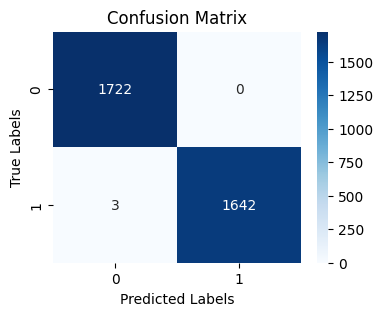

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute predictions
test_predictions = model(test_images)
test_pred_labels = tf.argmax(test_predictions, axis=1).numpy()

# Generate confusion matrix
cm = confusion_matrix(test_labels, test_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt

# Define representative dataset function for integer quantization
def representative_dataset():
    for i in range(100):  # Using a subset of training data
        yield [train_images[i: i + 1]]

# Ensure all variables are frozen before conversion
tf.lite.TFLiteConverter.experimental_new_converter = True

# Export the model to SavedModel format with a signature function
def serving_fn(inputs):
    return {"outputs": model(inputs)}

signature = tf.function(serving_fn).get_concrete_function(
    tf.TensorSpec(shape=[None, 32 * 32], dtype=tf.float32)
)

# Save model in Keras format instead of SavedModel
model.save("kan32_32.keras")

# Convert the model to TFLite format with different quantization methods
# 1. Default Quantization (Dynamic Range)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
dynamic_tflite_model = converter.convert()
with open("kan32_32_dynamic.tflite", "wb") as f:
    f.write(dynamic_tflite_model)
print("✅ Dynamic range quantized model saved as kan32_32_dynamic.tflite")

# 2. Float16 Quantization
converter.target_spec.supported_types = [tf.float16]
float16_tflite_model = converter.convert()
with open("kan32_32_float16.tflite", "wb") as f:
    f.write(float16_tflite_model)
print("✅ Float16 quantized model saved as kan32_32_float16.tflite")

# 3. Full Integer Quantization (with representative dataset)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
integer_tflite_model = converter.convert()
with open("kan32_32_integer.tflite", "wb") as f:
    f.write(integer_tflite_model)
print("✅ Full integer quantized model saved as kan32_32_integer.tflite")

# 4. Weight Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.OPTIMIZE_FOR_SIZE]
weight_tflite_model = converter.convert()
with open("kan32_32_weight.tflite", "wb") as f:
    f.write(weight_tflite_model)
print("✅ Weight quantized model saved as kan32_32_weight.tflite")


Saved artifact at '/tmp/tmpphiuc5ib'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136709279335440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279335632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136740070007312: TensorSpec(shape=(2,), dtype=tf.float32, name=None)
  136740070006928: TensorSpec(shape=(), dtype=tf.float32, name=None)
  136740070006736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279335056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279336592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279336208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279335248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279335824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136740070006544: TensorSpec(sha

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Full integer quantized model saved as kan32_32_integer.tflite
Saved artifact at '/tmp/tmp2ld9hd1w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136709279335440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279335632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136740070007312: TensorSpec(shape=(2,), dtype=tf.float32, name=None)
  136740070006928: TensorSpec(shape=(), dtype=tf.float32, name=None)
  136740070006736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279335056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279336592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279336208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279335248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709279335824: TensorSpec(shape=(),

✅ Weight quantized model saved as kan32_32_weight.tflite


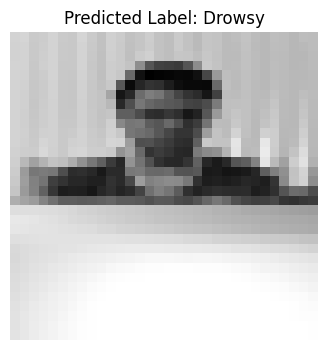

🖼️ Predicted Label: 1


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import matplotlib.pyplot as plt
from PIL import Image

# Define representative dataset function for integer quantization
def representative_dataset():
    for i in range(100):  # Using a subset of training data
        yield [train_images[i: i + 1]]

# Ensure all variables are frozen before conversion
tf.lite.TFLiteConverter.experimental_new_converter = True

# Export the model to SavedModel format with a signature function
def serving_fn(inputs):
    return {"outputs": model(inputs)}

signature = tf.function(serving_fn).get_concrete_function(
    tf.TensorSpec(shape=[None, 32 * 32], dtype=tf.float32)
)


# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan32_32_integer.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_13_frame_349.jpg").convert("L")  # Convert to grayscale
image = image.resize((32, 32))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 32 * 32)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.int8))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label}")



In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized dynamic model
interpreter = tf.lite.Interpreter(model_path="kan32_32_integer.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 32 * 32).astype(np.int8)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()
    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 48.86%
⏱️ Total Inference Time for 3367 Images: 206.48 ms
⏱️ Average Inference Time per Sample: 0.06 ms


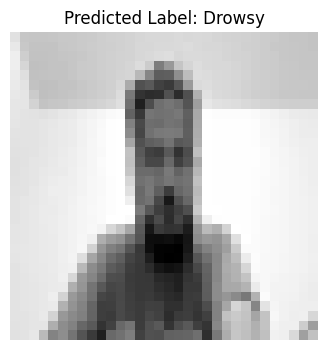

🖼️ Predicted Label: Drowsy


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan32_32_float16.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/drowsy/10_14_frame_15661.jpg").convert("L")  # Convert to grayscale
image = image.resize((32, 32))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 32 * 32)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")

In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized Float16 model
interpreter = tf.lite.Interpreter(model_path="kan32_32_float16.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 32 * 32).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.91%
⏱️ Total Inference Time for 3367 Images: 150.26 ms
⏱️ Average Inference Time per Sample: 0.04 ms


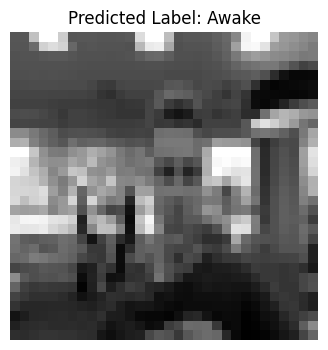

🖼️ Predicted Label: Awake


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan32_32_weight.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_11_frame_10201.jpg").convert("L")  # Convert to grayscale
image = image.resize((32, 32))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 32 * 32)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")


In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized Weight-Only model
interpreter = tf.lite.Interpreter(model_path="kan32_32_weight.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 32 * 32).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.91%
⏱️ Total Inference Time for 3367 Images: 141.75 ms
⏱️ Average Inference Time per Sample: 0.04 ms


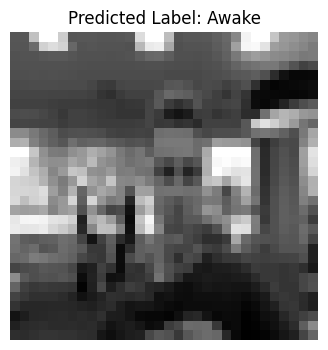

🖼️ Predicted Label: Awake


In [ ]:
# Load the quantized integer model
interpreter = tf.lite.Interpreter(model_path="kan32_32_dynamic.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess image
image = Image.open("/content/drive/MyDrive/UTARLDD_gray/UTARLDD_frames_gris/awake/0_11_frame_10201.jpg").convert("L")  # Convert to grayscale
image = image.resize((32, 32))
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = image_array.reshape(1, 32 * 32)

# Run inference
interpreter.set_tensor(input_details[0]['index'], image_array.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Define label names
label_names = {0: "Awake", 1: "Drowsy"}
predicted_label_name = label_names.get(predicted_label, "Unknown")

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Label: {predicted_label_name}")
plt.axis("off")
plt.show()

print(f"🖼️ Predicted Label: {predicted_label_name}")


In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load the quantized dynamic model
interpreter = tf.lite.Interpreter(model_path="kan32_32_dynamic.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load test dataset
# Assuming test_images and test_labels are already loaded as numpy arrays
correct_predictions = 0
total_start_time = time.time()  # Start measuring total inference time

for i in range(len(test_images)):
    image_array = test_images[i].reshape(1, 32 * 32).astype(np.float32)
    label = test_labels[i]

    # Measure inference time for a single image
    start_time = time.time()

    interpreter.set_tensor(input_details[0]['index'], image_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    end_time = time.time()

    if predicted_label == label:
        correct_predictions += 1

total_end_time = time.time()
total_inference_time = (total_end_time - total_start_time) * 1000  # Convert to milliseconds
avg_inference_time = total_inference_time / len(test_images)  # Compute average per image

# Compute accuracy
accuracy = correct_predictions / len(test_images) * 100

# Print results
print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Total Inference Time for {len(test_images)} Images: {total_inference_time:.2f} ms")
print(f"⏱️ Average Inference Time per Sample: {avg_inference_time:.2f} ms")


✅ Test Accuracy: 99.91%
⏱️ Total Inference Time for 3367 Images: 143.13 ms
⏱️ Average Inference Time per Sample: 0.04 ms


In [ ]:
# Convert kan150_150_dynamic.tflite to a C array
with open("kan32_32_dynamic.tflite", "rb") as f:
    tflite_model = f.read()

def convert_to_c_array(model_data, var_name="model_tflite32"):
    c_code = f"unsigned char {var_name}[] = {{\n"
    hex_array = [f"0x{b:02x}" for b in model_data]
    for i in range(0, len(hex_array), 12):
        c_code += "    " + ", ".join(hex_array[i:i+12]) + ",\n"
    c_code += "};\n"
    c_code += f"unsigned int {var_name}_len = {len(model_data)};\n"
    return c_code

c_code = convert_to_c_array(tflite_model, "kan150_150_dynamic")
with open("kan32_32_dynamic.cc", "w") as f:
    f.write(c_code)

print("✅ Converted kan32_32_dynamic.tflite to C array and saved as kan32_32_dynamic.cc")


✅ Converted kan32_32_dynamic.tflite to C array and saved as kan32_32_dynamic.cc


In [ ]:
# Print the C source file
!cat kan32_32_dynamic.cc

unsigned char kan150_150_dynamic[] = {
    0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
    0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
    0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
    0x84, 0x00, 0x00, 0x00, 0xd4, 0x00, 0x00, 0x00, 0x50, 0x61, 0x00, 0x00,
    0x60, 0x61, 0x00, 0x00, 0x68, 0x8c, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00,
    0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0xc6, 0x94, 0xff, 0xff,
    0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x3c, 0x00, 0x00, 0x00,
    0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f,
    0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00, 0x00,
    0x04, 0x00, 0x00, 0x00, 0x00, 0x97, 0xff, 0xff, 0x48, 0x00, 0x00, 0x00,
    0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00, 0x6f, 0x75, 0x74, 0x70,
    0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00,
    0x04, 0x00, 0x00, 0x00, 0x92, 0x98, 0xff, 0xf